In [602]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [603]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [604]:
len(words)

32033

In [605]:
#build a vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print('vocab', itos)
print('vocab size:', vocab_size)

vocab {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
vocab size: 27


In [606]:
# build the dataset

import random

def build_train_valid_test(words, block_size, stoi, train_ratio, valid_ratio, test_ratio):
    random.seed(42)
    random.shuffle(words)
    n1 = int(train_ratio*len(words))
    n2 = int((train_ratio + valid_ratio)*len(words))

    X_train, Y_train = build_dataset(words[:n1], block_size, stoi)
    X_valid, Y_valid = build_dataset(words[n1:n2], block_size, stoi)
    X_test, Y_test = build_dataset(words[n2:], block_size, stoi)

    return X_train, Y_train, X_valid, Y_valid, X_test, Y_test

def build_dataset(words, block_size, stoi):
    X, Y = [], []
    for w in words:

        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    return torch.tensor(X), torch.tensor(Y)

block_size = 3 # context length - how many charachters do we take to predict the next one
X_train, Y_train, X_valid, Y_valid, X_test, Y_test = build_train_valid_test(words, block_size, stoi, 0.8, 0.1, 0.1)

In [607]:
hidden_layer_size = 200
embedding_dim = 10
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embedding_dim), generator=g)
W1 = torch.randn((block_size * embedding_dim, hidden_layer_size), generator=g) * (5.0/3.0)/((block_size * embedding_dim)**0.5)
#b1 = torch.randn(hidden_layer_size, generator=g) * 0.01
W2 = torch.randn((hidden_layer_size, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

bngain = torch.ones((1, hidden_layer_size))
bnbais = torch.zeros((1, hidden_layer_size))
bnmean_running = torch.zeros((1, hidden_layer_size))
bnstd_running = torch.ones((1, hidden_layer_size))

parameters = [C, W1, W2, b2, bngain, bnbais]

print('parameters count', sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

parameters count 12097


In [608]:
import math

from matplotlib.pyplot import plot
from torch import log10

iterations = 10000
batch_size = 32

#lre = torch.linspace(-3, 0, iterations)
#lrs = 10**lre
#use above parameters toplot losses vs learning rates to determine the best learning rate

lrs = [0.1, 0.01]
epochs = len(lrs)

steps, losses = [], []
lri, lsi = [], []
for epoch in range(epochs):
    learning_rate = lrs[epoch]

    for iter in range(iterations):

        # batch construction
        ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)

        # forward pass
        emb = C[X_train[ix]]
        embcat = emb.view(-1, block_size * embedding_dim)
        # linear layer
        hreact = embcat @ W1 # + b1
        # batch normalization
        # ---------------------------------------------------------------------------------------------
        bnmeani = hreact.mean(0, keepdim=True)
        bnstdi = hreact.std(0, keepdim=True)
        hreact = bngain * (hreact - bnmeani) / (bnstdi + 1e-6) + bnbais

        with torch.no_grad():
            bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
            bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
        # ---------------------------------------------------------------------------------------------

        # nonlinearity
        h = torch.tanh(hreact)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Y_train[ix])

        # backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        # update
        for p in parameters:
            p.data += -learning_rate * p.grad

        step = iter + epoch * iterations
        if step % 1000 == 0:
            print(step, '/', iterations * epochs, 'learning_rate', learning_rate, 'loss', loss.item())

        # to plot iteration vs loss
        steps.append(step)
        losses.append(loss.log10().item())

0 / 20000 learning_rate 0.1 loss 3.3238625526428223
1000 / 20000 learning_rate 0.1 loss 2.4625232219696045
2000 / 20000 learning_rate 0.1 loss 2.3617725372314453
3000 / 20000 learning_rate 0.1 loss 2.161384105682373
4000 / 20000 learning_rate 0.1 loss 1.995882511138916
5000 / 20000 learning_rate 0.1 loss 2.097090482711792
6000 / 20000 learning_rate 0.1 loss 2.1198318004608154
7000 / 20000 learning_rate 0.1 loss 2.336620569229126
8000 / 20000 learning_rate 0.1 loss 1.802078366279602
9000 / 20000 learning_rate 0.1 loss 2.494285821914673
10000 / 20000 learning_rate 0.01 loss 2.0321619510650635
11000 / 20000 learning_rate 0.01 loss 2.0788064002990723
12000 / 20000 learning_rate 0.01 loss 1.9448440074920654
13000 / 20000 learning_rate 0.01 loss 2.28466796875
14000 / 20000 learning_rate 0.01 loss 1.905739665031433
15000 / 20000 learning_rate 0.01 loss 2.5999298095703125
16000 / 20000 learning_rate 0.01 loss 2.260418176651001
17000 / 20000 learning_rate 0.01 loss 2.4807522296905518
18000 / 20

(array([222., 188., 155., 154., 123., 158., 130., 107., 129., 151., 144.,
        152., 114.,  95.,  80., 116., 135., 116., 130.,  92., 119.,  86.,
         95.,  86., 102.,  95.,  97., 125., 100.,  79., 130., 128., 143.,
        152., 143., 111., 150.,  95., 131.,  95., 139., 135.,  78., 123.,
        138., 112., 170., 133., 186., 233.]),
 array([-9.99671519e-01, -9.59689035e-01, -9.19706552e-01, -8.79724069e-01,
        -8.39741585e-01, -7.99759102e-01, -7.59776618e-01, -7.19794135e-01,
        -6.79811652e-01, -6.39829168e-01, -5.99846685e-01, -5.59864202e-01,
        -5.19881718e-01, -4.79899235e-01, -4.39916751e-01, -3.99934268e-01,
        -3.59951785e-01, -3.19969301e-01, -2.79986818e-01, -2.40004334e-01,
        -2.00021851e-01, -1.60039368e-01, -1.20056884e-01, -8.00744009e-02,
        -4.00919175e-02, -1.09434128e-04,  3.98730493e-02,  7.98555326e-02,
         1.19838016e-01,  1.59820499e-01,  1.99802983e-01,  2.39785466e-01,
         2.79767950e-01,  3.19750433e-01,  3.59732

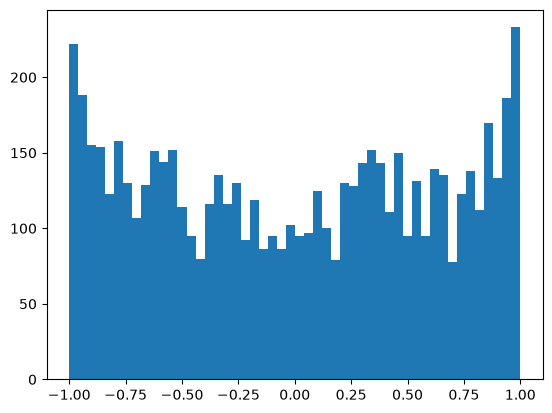

In [609]:
plt.hist(h.view(-1).tolist(), bins=50)

(array([  1.,   0.,   0.,   0.,   3.,   4.,   8.,  13.,  15.,  16.,  18.,
         40.,  34.,  51.,  83.,  89., 106., 148., 164., 234., 237., 395.,
        373., 424., 430., 390., 427., 543., 456., 297., 283., 243., 161.,
        169., 111.,  99.,  81.,  75.,  53.,  39.,  33.,  18.,   8.,   5.,
          8.,   8.,   2.,   2.,   0.,   3.]),
 array([-4.35703945, -4.18786553, -4.01869162, -3.8495177 , -3.68034378,
        -3.51116986, -3.34199594, -3.17282203, -3.00364811, -2.83447419,
        -2.66530027, -2.49612636, -2.32695244, -2.15777852, -1.9886046 ,
        -1.81943069, -1.65025677, -1.48108285, -1.31190893, -1.14273501,
        -0.9735611 , -0.80438718, -0.63521326, -0.46603934, -0.29686543,
        -0.12769151,  0.04148241,  0.21065633,  0.37983025,  0.54900416,
         0.71817808,  0.887352  ,  1.05652592,  1.22569983,  1.39487375,
         1.56404767,  1.73322159,  1.90239551,  2.07156942,  2.24074334,
         2.40991726,  2.57909118,  2.74826509,  2.91743901,  3.08661293,
 

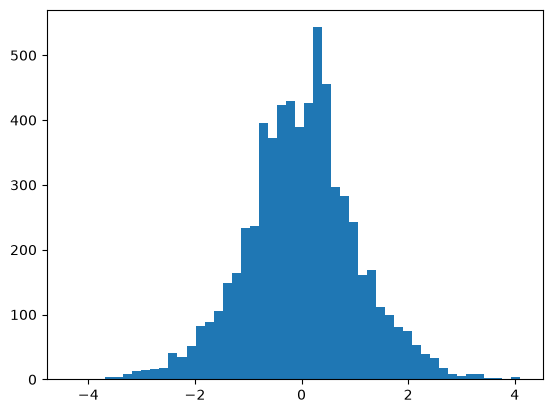

In [610]:
plt.hist(hreact.view(-1).tolist(), bins=50)

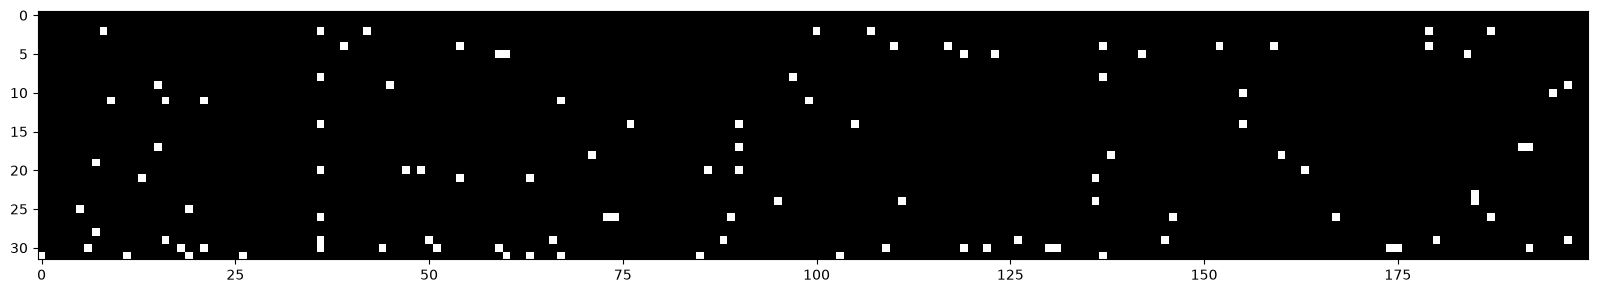

In [611]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

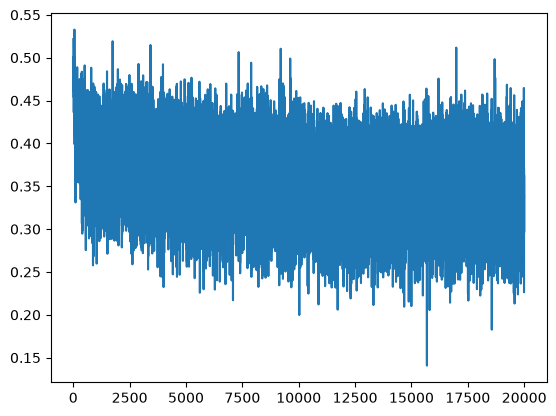

In [612]:
plt.plot(losses)

In [613]:
@torch.no_grad() # to let know pytorch that this code requires no gradients calculations
def split_loss(split):
    x, y = {
        'train': (X_train, Y_train),
        'valid': (X_valid, Y_valid),
        'test': (X_test, Y_test),
    }[split]

    # forward pass
    emb = C[x]
    embcat = emb.view(-1, block_size * embedding_dim)
    hreact = embcat @ W1 # + b1
    hreact = bngain * (hreact - bnmean_running) / (bnstd_running + 1e-6) + bnbais
    h = torch.tanh(hreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss('train')
split_loss('valid')
split_loss('test')
    

train 2.187634229660034
valid 2.1955106258392334
test 2.2001471519470215


In [614]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / (fan_in**0.5)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate forward pass
        if self.training:
            x_mean = x.mean(0, keepdim=True) # batch mean
            x_var = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            x_mean = self.running_mean
            x_var = self.running_var
        
        xhat = (x - x_mean) / torch.sqrt(x_var + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # scale and shift

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * x_mean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * x_var

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    
n_embed = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embed), generator=g)
layers = [
    Linear(n_embed * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),           BatchNorm1d(vocab_size), 
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1

    parameters = [C] + [p for layer in layers for p in layer.parameters()]
    print('number of parameters in the model:', sum(p.nelement() for p in parameters))
    for p in parameters:
        p.requires_grad = True

number of parameters in the model: 57851


In [615]:
batch_size = 32
iterations = 10000

lrs = [0.03, 0.01, 0.003]
epochs = len(lrs)
iterations_per_epoch = iterations // epochs

losses = []
ud = []

for epoch in range(epochs):
    learning_rate = lrs[epoch]

    for iter in range(iterations_per_epoch):

        # minibatch construct
        ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
        Xb, Yb = X_train[ix], Y_train[ix]

        # forward pass
        emb = C[Xb]
        x = emb.view(-1, block_size * n_embed)
        for layer in layers:
            x = layer(x)
        loss = F.cross_entropy(x, Yb) # loss function

        # backward pass
        for layer in layers:
            layer.out.retain_grad() # retain the gradients of the outputs of each layer for analysis
        for p in parameters:
            p.grad = None
        loss.backward()

        # update
        for p in parameters:
            p.data += -learning_rate * p.grad

        #track stats
        step = iter + epoch * iterations_per_epoch
        if step % (iterations // 20) == 0:
            print(f'{step:7d}/{iterations:7d}: {loss.item():.4f} lr={learning_rate}')
        losses.append(loss.log10().item())

        with torch.no_grad():
            ud.append([(learning_rate*p.grad.std() / p.data.std()).log10().item() for p in parameters])

      0/  10000: 3.2932 lr=0.03
    500/  10000: 2.7533 lr=0.03
   1000/  10000: 2.1910 lr=0.03
   1500/  10000: 2.4136 lr=0.03
   2000/  10000: 2.5727 lr=0.03
   2500/  10000: 2.4760 lr=0.03
   3000/  10000: 2.3807 lr=0.03
   3500/  10000: 2.4986 lr=0.01
   4000/  10000: 2.3907 lr=0.01
   4500/  10000: 2.6344 lr=0.01
   5000/  10000: 2.1217 lr=0.01
   5500/  10000: 2.4631 lr=0.01
   6000/  10000: 2.4121 lr=0.01
   6500/  10000: 2.1741 lr=0.01
   7000/  10000: 1.8467 lr=0.003
   7500/  10000: 2.7497 lr=0.003
   8000/  10000: 2.4948 lr=0.003
   8500/  10000: 1.9664 lr=0.003
   9000/  10000: 2.2950 lr=0.003
   9500/  10000: 2.1066 lr=0.003


Layer 2 (      Tanh): mean -0.00, std 0.63, saturated 0.03
Layer 5 (      Tanh): mean +0.00, std 0.65, saturated 0.02
Layer 8 (      Tanh): mean -0.01, std 0.64, saturated 0.03
Layer 11 (      Tanh): mean +0.00, std 0.65, saturated 0.02
Layer 14 (      Tanh): mean +0.00, std 0.65, saturated 0.02
Layer 17 (      Tanh): mean +0.00, std 0.65, saturated 0.02


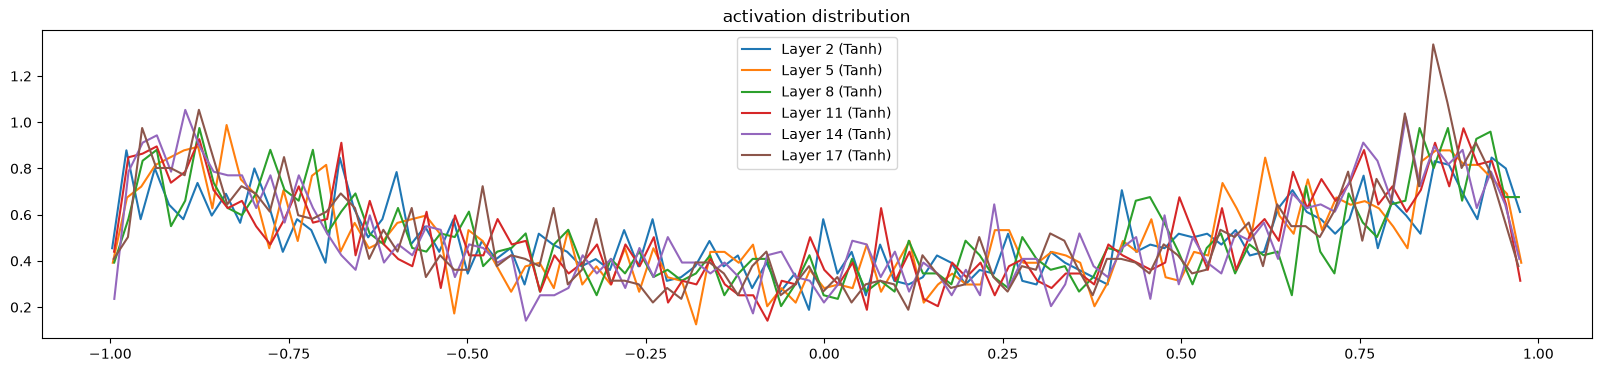

In [616]:
#visualize histograms
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print(f'Layer %d (%10s): mean %+.2f, std %.2f, saturated %.2f' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i} ({layer.__class__.__name__})')
    plt.legend(legends)
    plt.title('activation distribution')

Layer 2 (      Tanh): mean +0.00, std 0.00, saturated 0.00
Layer 5 (      Tanh): mean -0.00, std 0.00, saturated 0.00
Layer 8 (      Tanh): mean +0.00, std 0.00, saturated 0.00
Layer 11 (      Tanh): mean -0.00, std 0.00, saturated 0.00
Layer 14 (      Tanh): mean -0.00, std 0.00, saturated 0.00
Layer 17 (      Tanh): mean +0.00, std 0.00, saturated 0.00


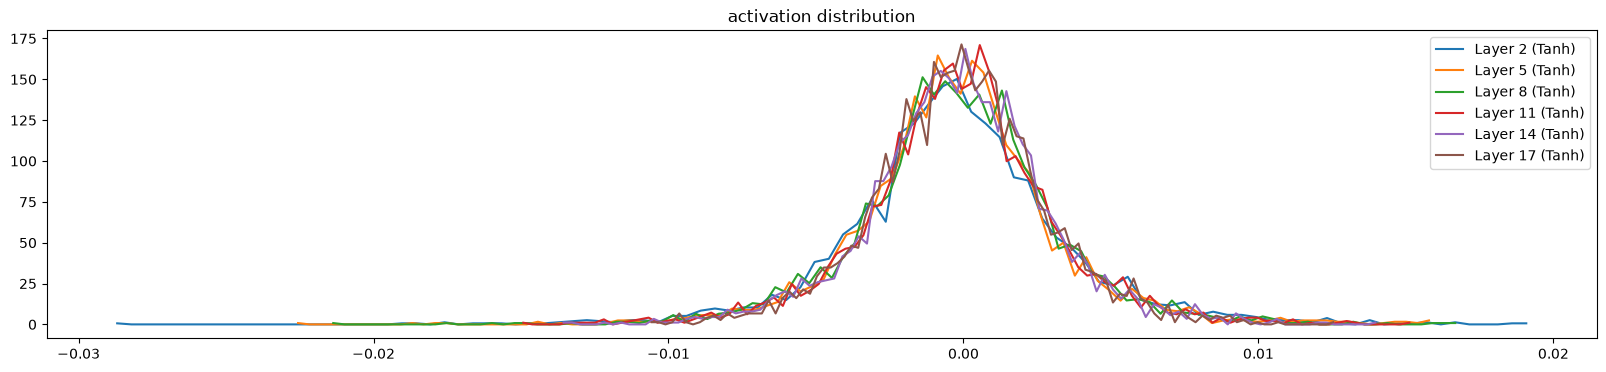

In [617]:
#visualize histograms
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print(f'Layer %d (%10s): mean %+.2f, std %.2f, saturated %.2f' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i} ({layer.__class__.__name__})')
    plt.legend(legends)
    plt.title('activation distribution')

weight   (27, 10) | mean -0.000000 | std 1.367989e-02 | grad:data ratio 1.366799e-02
weight  (30, 100) | mean -0.000317 | std 1.602962e-02 | grad:data ratio 8.494689e-02
weight (100, 100) | mean +0.000098 | std 1.251385e-02 | grad:data ratio 1.229555e-01
weight (100, 100) | mean -0.000188 | std 1.130645e-02 | grad:data ratio 1.104700e-01
weight (100, 100) | mean -0.000016 | std 1.037576e-02 | grad:data ratio 1.019289e-01
weight (100, 100) | mean +0.000036 | std 9.460125e-03 | grad:data ratio 9.307196e-02
weight (100, 100) | mean -0.000118 | std 9.266285e-03 | grad:data ratio 9.262931e-02
weight  (100, 27) | mean +0.000064 | std 1.776971e-02 | grad:data ratio 1.707935e-01


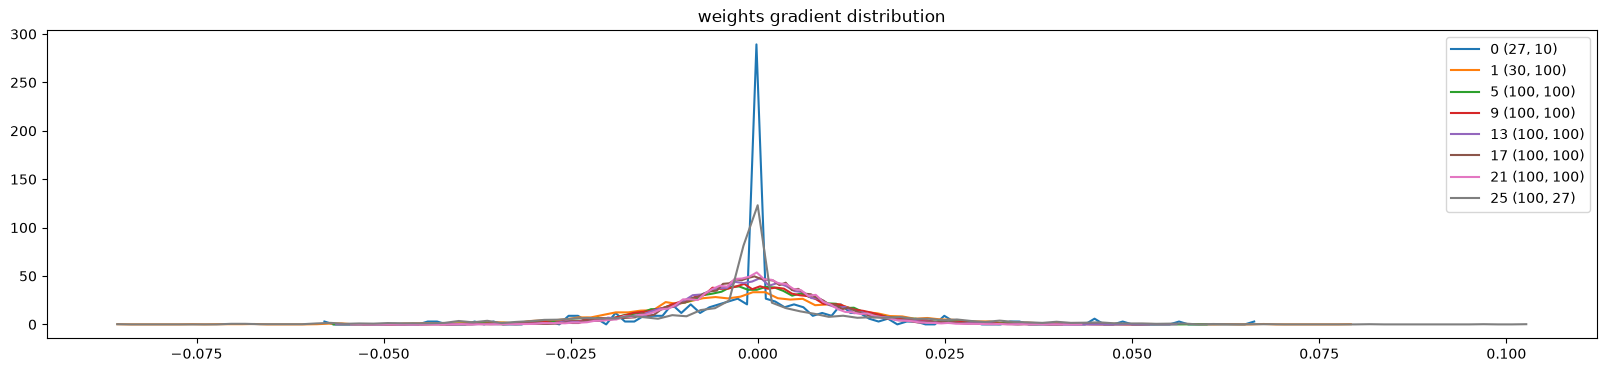

In [618]:
#visualize histograms
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
    plt.legend(legends)
    plt.title('weights gradient distribution')

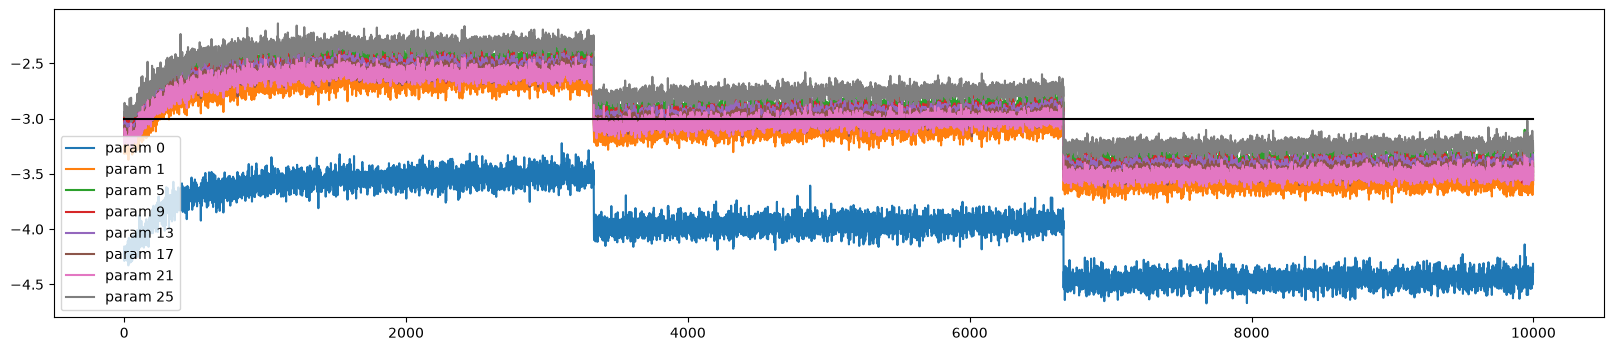

In [619]:
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends)

In [620]:
# sampling from the trained neural net
g = torch.Generator().manual_seed(2147483647 + 10)

for i in range(25):

    out = []
    context = [0] * block_size
    
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))
        


chrmahxlan.
hlvifk.
mrrigthfl.
skand.
gejmahntrflgwryrc.
kaqhign.
zmari.
chriiv.
janeggbdhlm.
jocelqhnjuis.
lilla.
jadbi.
wavthmadearixmiri.
gulins.
bred.
gdig.
bgtlffrystry.
amasmind.
hmsya.
dmbborozeljlojnnn.
camrrendep.
sadln.
gdnoelsttorazgrynd.
ammilmanr.
add.
